In [1]:
!pip install ucimlrepo
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import time
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor,RandomForestClassifier, RandomForestRegressor

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

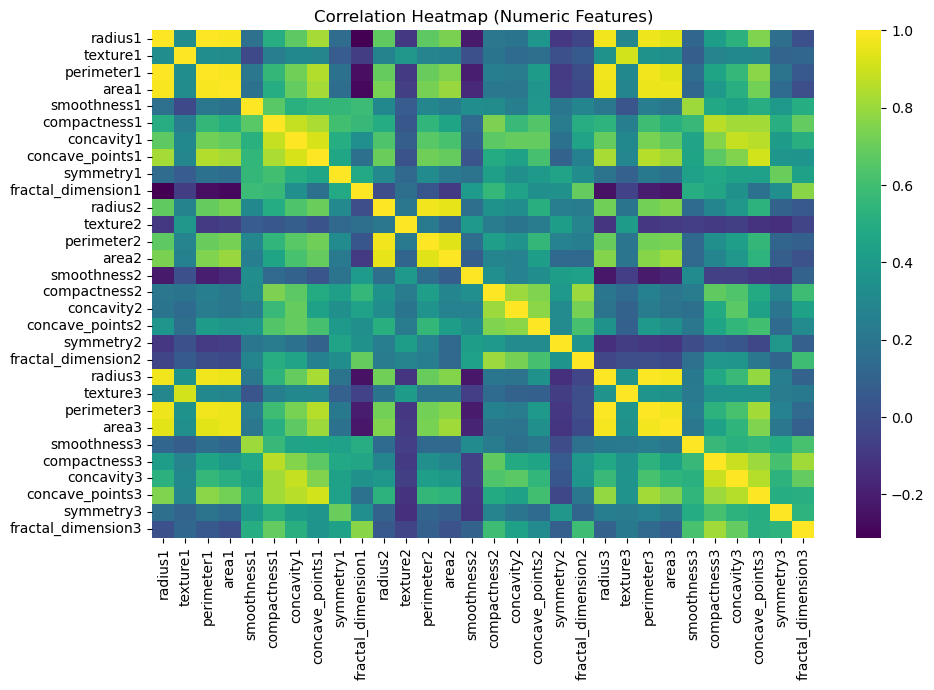

<Figure size 640x480 with 0 Axes>

In [3]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

corr = X[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()
plt.savefig( "correlation5.eps", format="eps", dpi=600, bbox_inches="tight" )

# Obs:
We can see that radius, perimeter and area of mean, std error and largest are correlating, and 
compactness, concavity and concave_points are also correlated.

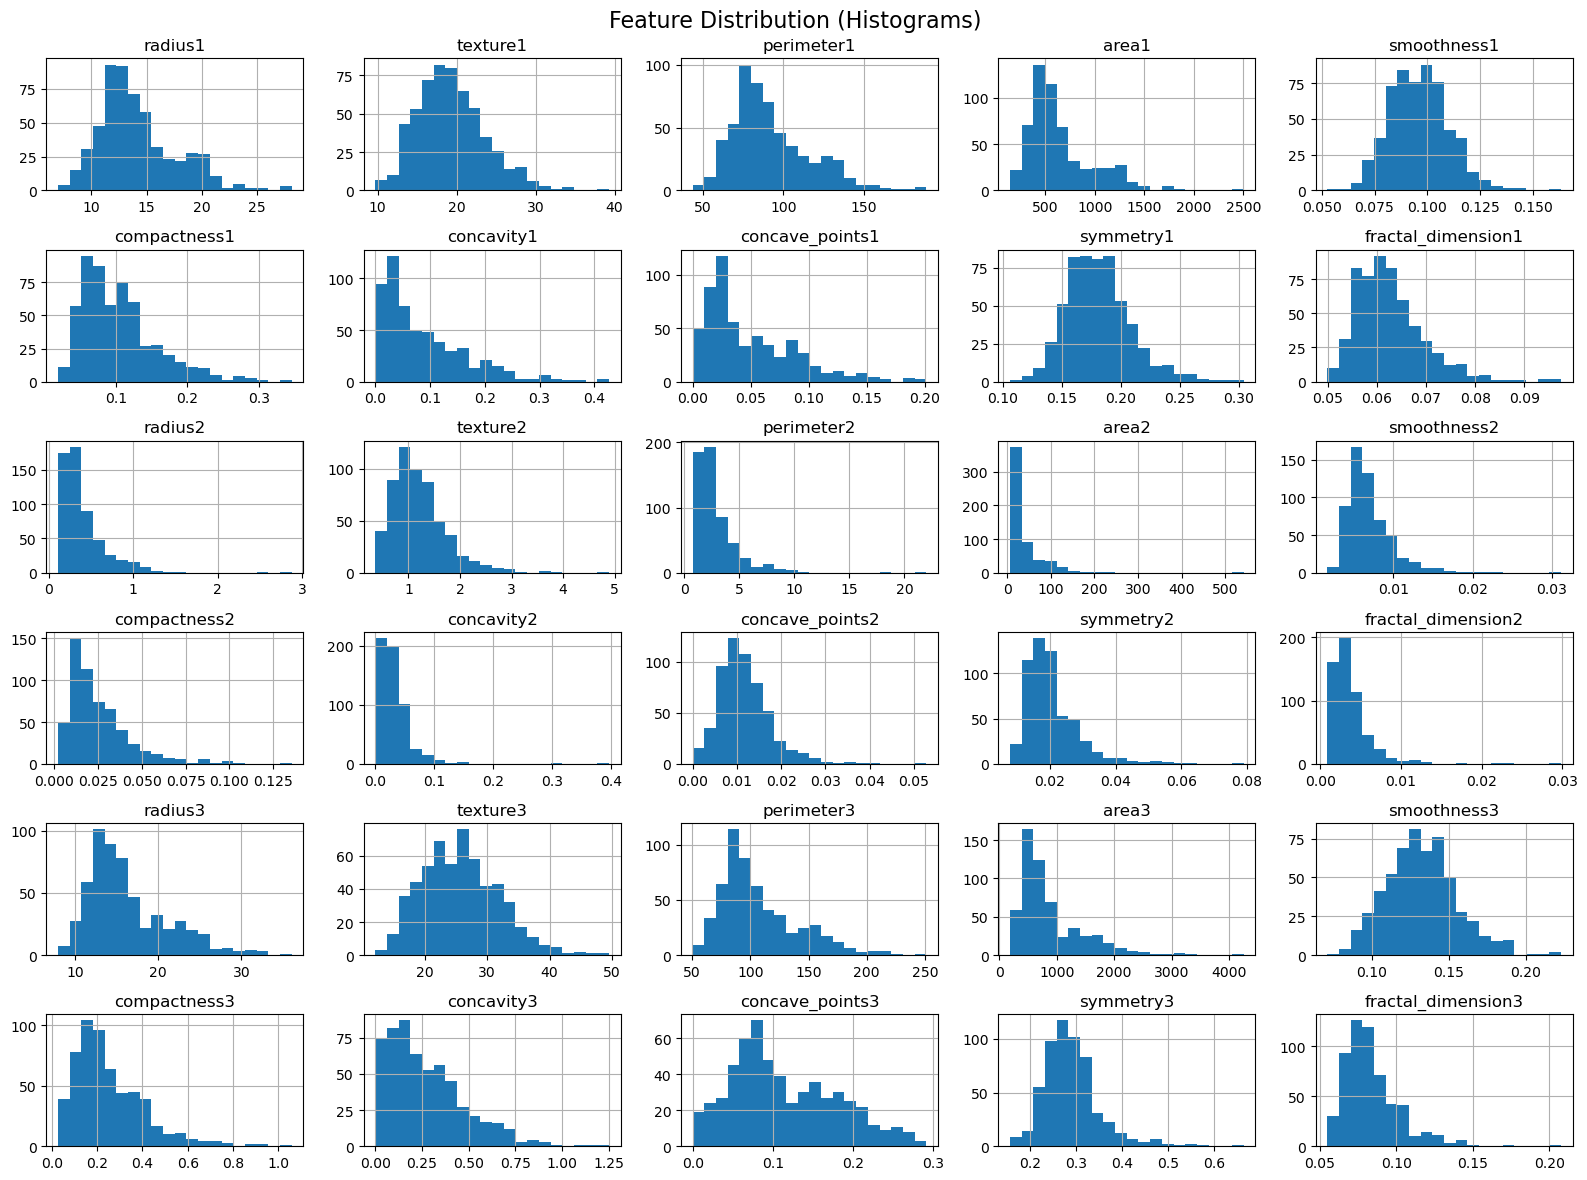

In [4]:


X.hist(bins=20, figsize=(16, 12))
plt.suptitle("Feature Distribution (Histograms)", fontsize=16)
plt.tight_layout()
plt.savefig( "assign6_feature.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()



In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y.iloc[:, 0]
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(y_train.value_counts(normalize=True), "\n---\n", y_test.value_counts(normalize=True))

(455, 30) (114, 30) (455, 1) (114, 1)
Diagnosis
B            0.626374
M            0.373626
Name: proportion, dtype: float64 
---
 Diagnosis
B            0.631579
M            0.368421
Name: proportion, dtype: float64


Classification Report:
               precision    recall  f1-score   support

           B       0.88      1.00      0.94        72
           M       1.00      0.76      0.86        42

    accuracy                           0.91       114
   macro avg       0.94      0.88      0.90       114
weighted avg       0.92      0.91      0.91       114



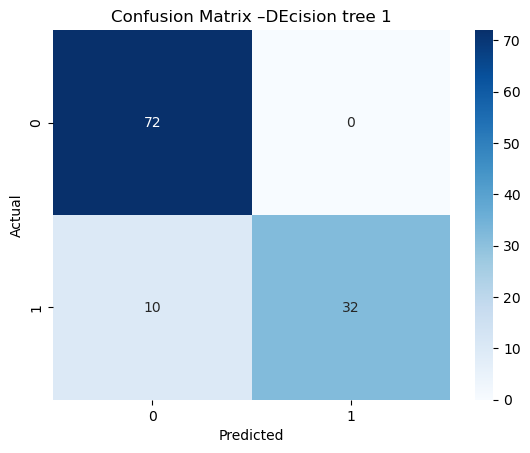

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
decitree1 = DecisionTreeClassifier(
criterion="gini",
max_depth=100,
min_samples_split=2,
min_samples_leaf=10,
random_state=42
)

decitree1.fit(X_train,y_train)
y_pred=decitree1.predict(X_test)
print("Classification Report:\n",classification_report(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
tn, fp, fn, tp = cm.ravel()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix –DEcision tree 1")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig( "assign6_confdec1.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best CV score: 0.9362637362637363
Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Fold-wise Accuracies: [np.float64(0.9010989010989011), np.float64(0.9560439560439561), np.float64(0.9120879120879121), np.float64(0.9560439560439561), np.float64(0.9560439560439561)]
Best Model Params: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Classification Report:
               precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
we

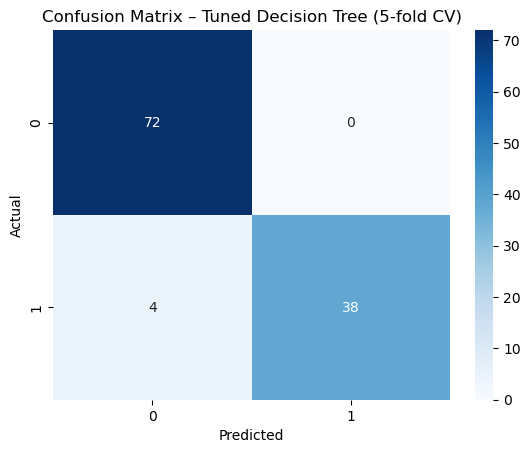

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


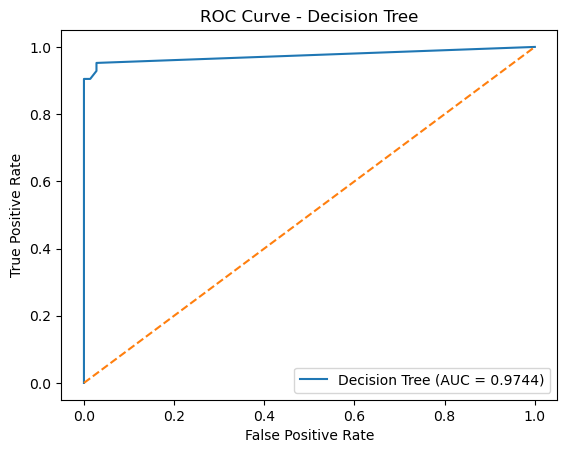

    rank_test_score  mean_test_score  std_test_score  \
50                1         0.936264        0.024474   
59                2         0.934066        0.025059   
68                2         0.934066        0.025059   
47                4         0.929670        0.020382   
22                4         0.929670        0.027451   
31                4         0.929670        0.027451   
57                7         0.929670        0.023671   
58                7         0.929670        0.023671   
8                 7         0.929670        0.022628   
6                 7         0.929670        0.022628   

                                               params  
50  {'criterion': 'entropy', 'max_depth': 5, 'min_...  
59  {'criterion': 'entropy', 'max_depth': 7, 'min_...  
68  {'criterion': 'entropy', 'max_depth': 10, 'min...  
47  {'criterion': 'entropy', 'max_depth': 5, 'min_...  
22  {'criterion': 'gini', 'max_depth': 7, 'min_sam...  
31  {'criterion': 'gini', 'max_depth': 10, 'min

In [8]:

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def tune_decision_tree_cv(
    X_train, y_train,
    param_grid=None,
    scoring="accuracy",
    cv_splits=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
):
    """
    Tunes DecisionTreeClassifier hyperparameters using k-fold CV (default 5).
    Returns: best_estimator, grid_search_object, cv_results_df
    """

    # Default grid (edit as needed)
    if param_grid is None:
        param_grid = {
            "criterion": ["gini", "entropy"],
            "max_depth": [3, 5, 7, 10],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5],
        }

    # If y_train is a DataFrame, convert to 1D
    if hasattr(y_train, "shape") and len(getattr(y_train, "shape", [])) == 2 and y_train.shape[1] == 1:
        y_train_1d = y_train.iloc[:, 0]
    else:
        y_train_1d = y_train

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    base_model = DecisionTreeClassifier(random_state=random_state)

    gs = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose,
        refit=refit,
        return_train_score=True,
    )
    
    gs.fit(X_train, y_train_1d)
    try:
        import pandas as pd
        results_df = pd.DataFrame(gs.cv_results_).sort_values("rank_test_score")
    except Exception:
        results_df = None

    return gs.best_estimator_, gs, results_df


def evaluate_model_with_cm(model, X_test, y_test, title="Confusion Matrix", save_path=None):
    # If y_test is a DataFrame, convert to 1D
    if hasattr(y_test, "shape") and len(getattr(y_test, "shape", [])) == 2 and y_test.shape[1] == 1:
        y_test_1d = y_test.iloc[:, 0]
    else:
        y_test_1d = y_test

    y_pred = model.predict(X_test)

    print("Best Model Params:", getattr(model, "get_params", lambda: {})())
    print("\nClassification Report:\n", classification_report(y_test_1d, y_pred))

    cm = confusion_matrix(y_test_1d, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    if save_path:
        plt.savefig(save_path, format="eps", dpi=600, bbox_inches="tight")

    plt.show()
    return cm, y_pred

best_tree, gs, results_df = tune_decision_tree_cv(
    X_train, y_train,
    scoring="accuracy",          # for binary classification; you can also use "accuracy"
    cv_splits=5
)

print("Best CV score:", gs.best_score_)
print("Best params:", gs.best_params_)
cv_results = pd.DataFrame(gs.cv_results_)

# Get best model index
best_idx = gs.best_index_

# Extract fold-wise scores
fold_scores = [
    cv_results.loc[best_idx, f"split{i}_test_score"]
    for i in range(5)
]

print("Fold-wise Accuracies:", fold_scores)
evaluate_model_with_cm(
    best_tree, X_test, y_test,
    title="Confusion Matrix – Tuned Decision Tree (5-fold CV)",
    save_path="assign6_confdec_tuned.eps"
)
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)

# Predict probabilities
y_prob = gs.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='Decision Tree (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')

plt.savefig('decision_tree_roc.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()
if results_df is not None:
    print(results_df[["rank_test_score","mean_test_score","std_test_score","params"]].head(10))

In [9]:
from sklearn.metrics import make_scorer, f1_score
def tune_random_forest_cv(
    X_train, y_train,
    param_grid=None,
    cv_splits=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
):
    '''
    Tunes RandomForestClassifier hyperparameters using 5-fold Stratified CV.
    Uses multi-metric scoring to report both Accuracy and F1.
    Returns: best_estimator, grid_search_object, cv_results_df
    '''

    if param_grid is None:
        param_grid = {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, 15],
            "max_features": ["sqrt", "log2"],
            "bootstrap": [True, False]
        }

    # If y_train is a DataFrame, convert to 1D
    if hasattr(y_train, "shape") and len(getattr(y_train, "shape", [])) == 2 and y_train.shape[1] == 1:
        y_train_1d = y_train.iloc[:, 0]
    else:
        y_train_1d = y_train

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    base_model = RandomForestClassifier(random_state=random_state)

    scoring = {
    "accuracy": "accuracy",
    "f1": make_scorer(f1_score, pos_label="M")
    }
    gs = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scoring,
        refit="accuracy",          # choose best by accuracy (can change to "f1")
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose,
        return_train_score=True,
    )

    gs.fit(X_train, y_train_1d)

    results_df = pd.DataFrame(gs.cv_results_).sort_values("rank_test_accuracy")

    return gs.best_estimator_, gs, results_df


def evaluate_model_rf(model, X_test, y_test, title="Confusion Matrix", save_path=None, roc_save_path=None, pos_label=None):
    # y_test to 1D
    if hasattr(y_test, "shape") and len(getattr(y_test, "shape", [])) == 2 and y_test.shape[1] == 1:
        y_test_1d = y_test.iloc[:, 0]
    else:
        y_test_1d = y_test

    y_pred = model.predict(X_test)

    print("Best Model Params:", model.get_params())
    print("\nClassification Report:\n", classification_report(y_test_1d, y_pred))

    cm = confusion_matrix(y_test_1d, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    if save_path:
        plt.savefig(save_path, format="eps", dpi=600, bbox_inches="tight")
    plt.show()

    # ROC + AUC (need probabilities for positive class)
    if hasattr(model, "predict_proba"):
        # Get the index of the positive class in the classes_ attribute
        if pos_label is not None:
            if hasattr(model, "classes_"):
                pos_idx = np.where(model.classes_ == pos_label)[0][0]
            else:
                # If model doesn't have classes_ attribute, assume binary and pos_label is the second class
                pos_idx = 1
        else:
            # Default to the second class if pos_label not specified
            pos_idx = 1
            
        y_score = model.predict_proba(X_test)[:, pos_idx]
        fpr, tpr, _ = roc_curve(y_test_1d, y_score, pos_label=pos_label)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve – Random Forest")
        plt.legend(loc="lower right")
        if roc_save_path:
            plt.savefig(roc_save_path, format="eps", dpi=600, bbox_inches="tight")
        plt.show()

        print("ROC AUC:", roc_auc)

    return cm, y_pred

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV Accuracy: 0.9714285714285715
Best Params: {'bootstrap': False, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}
Fold-wise Accuracies: [np.float64(0.9560439560439561), np.float64(1.0), np.float64(0.945054945054945), np.float64(0.967032967032967), np.float64(0.989010989010989), np.float64(0.9393939393939394), np.float64(1.0), np.float64(0.9230769230769231), np.float64(0.9565217391304348), np.float64(0.9850746268656716)]
Best Model Params: {'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Classification Report:
               precision    recall  f1-sc

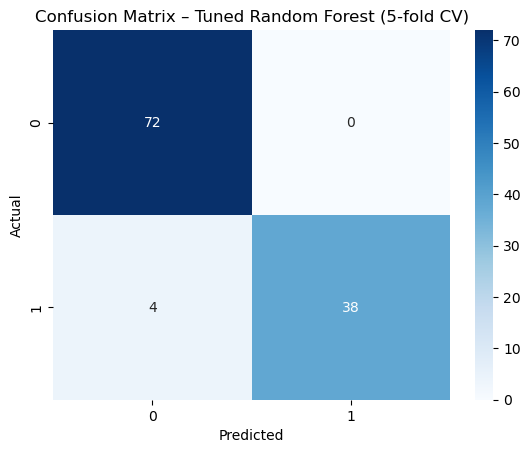

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


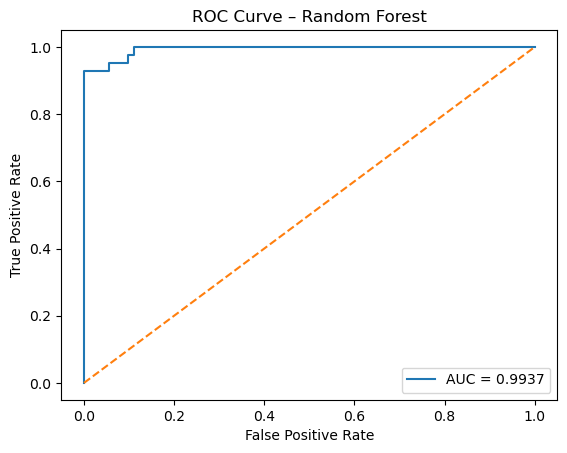

ROC AUC: 0.9937169312169312

Top 10 Random Forest CV configurations:


,rank_test_accuracy,mean_test_accuracy,mean_test_f1,params
31,1,0.971429,0.961529,"{'bootstrap': False, 'max_depth': 15, 'max_fea..."
25,1,0.971429,0.961529,"{'bootstrap': False, 'max_depth': 10, 'max_fea..."
20,1,0.971429,0.960813,"{'bootstrap': False, 'max_depth': 5, 'max_feat..."
19,1,0.971429,0.960813,"{'bootstrap': False, 'max_depth': 5, 'max_feat..."
35,5,0.969231,0.958459,"{'bootstrap': False, 'max_depth': 15, 'max_fea..."
27,5,0.969231,0.958469,"{'bootstrap': False, 'max_depth': 10, 'max_fea..."
18,5,0.969231,0.958016,"{'bootstrap': False, 'max_depth': 5, 'max_feat..."
33,8,0.967033,0.955570,"{'bootstrap': False, 'max_depth': 15, 'max_fea..."
29,8,0.967033,0.955565,"{'bootstrap': False, 'max_depth': 10, 'max_fea..."
21,8,0.967033,0.955038,"{'bootstrap': False, 'max_depth': 5, 'max_feat..."


In [10]:
best_rf, rf_gs, rf_results_df = tune_random_forest_cv(
    X_train, y_train,
    cv_splits=5,
    random_state=42,
    verbose=1
)

print("Best CV Accuracy:", rf_gs.best_score_)
print("Best Params:", rf_gs.best_params_)
cv_results = pd.DataFrame(rf_gs.cv_results_)

# Get best model index
best_idx = rf_gs.best_index_

# Extract fold-wise scores - check for the correct column names
# First, find the actual split column names in the DataFrame
split_columns = [col for col in cv_results.columns if col.startswith('split') and 'test' in col]

# Extract fold-wise scores using the correct column names
fold_scores = [
    cv_results.loc[best_idx, split_col]
    for split_col in split_columns
]

print("Fold-wise Accuracies:", fold_scores)
# Save confusion matrix + ROC curve as EPS
evaluate_model_rf(
    best_rf, X_test, y_test,
    title="Confusion Matrix – Tuned Random Forest (5-fold CV)",
    save_path="assign6_confrf_tuned.eps",
    roc_save_path="assign6_rocrf_tuned.eps",
    pos_label="M"
)

# Table 2-like output: show top 10 configurations with Avg CV Accuracy and Avg CV F1
cols_to_show = ["rank_test_accuracy", "mean_test_accuracy", "mean_test_f1", "params"]
print("\nTop 10 Random Forest CV configurations:")
display(rf_results_df[cols_to_show].head(10))